# U-Net de débruitage + processus inverse — smoke test

Vérifie, avant l'entraînement complet (Phase 2 de `PLANNING.md`), que toute la mécanique DDPM fonctionne de bout en bout : shapes sur un batch, loss qui décroît sur quelques centaines de pas, boucle d'échantillonnage complète x_T -> x_0, sauvegarde d'échantillons à intervalles réguliers. Ce n'est **pas** l'entraînement baseline (trop court pour générer des images réalistes) — juste une vérification mécanique.

In [1]:
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import torch

from src.data.dataset import get_dataloaders, load_config
from src.models.ddpm.diffusion import GaussianDiffusion
from src.models.ddpm.unet import UNet
from src.utils.seed import set_seed
from src.utils.viz import save_sample_grid

set_seed(42)

data_config = load_config(Path.cwd().parent / "configs" / "data.yaml")
ddpm_config = load_config(Path.cwd().parent / "configs" / "ddpm_base.yaml")
model_config = ddpm_config["model"]

model = UNet(
    in_channels=model_config["in_channels"],
    base_channels=model_config["base_channels"],
    channel_mults=tuple(model_config["channel_mults"]),
    num_res_blocks=model_config["num_res_blocks"],
)
diffusion = GaussianDiffusion(
    timesteps=ddpm_config["timesteps"],
    schedule=ddpm_config["schedule"],
    beta_start=ddpm_config["beta_start"],
    beta_end=ddpm_config["beta_end"],
)

n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net : {n_params:,} paramètres")

U-Net : 3,541,569 paramètres


## 1. Vérification des shapes sur un batch

In [2]:
train_loader, _, _ = get_dataloaders(data_config)
batch_x, _ = next(iter(train_loader))
t = torch.randint(0, diffusion.timesteps, (batch_x.shape[0],))

predicted_noise = model(batch_x, t)
loss = diffusion.p_losses(model, batch_x, t)

print(f"batch_x     : {tuple(batch_x.shape)}")
print(f"pred. noise : {tuple(predicted_noise.shape)} (doit correspondre à batch_x)")
print(f"loss initiale (poids aléatoires) : {loss.item():.4f}")
assert predicted_noise.shape == batch_x.shape

batch_x     : (128, 1, 32, 32)
pred. noise : (128, 1, 32, 32) (doit correspondre à batch_x)
loss initiale (poids aléatoires) : 1.0444


## 2. Quelques centaines de pas d'optimisation — la loss doit décroître

Pas un entraînement complet (voir Phase 2 `PLANNING.md` pour la baseline), juste une vérification que le gradient circule correctement dans le U-Net et que la loss MSE est bien apprenable.

step  100/300 — loss=0.0898 (moy. 50 derniers: 0.0973)


step  200/300 — loss=0.0620 (moy. 50 derniers: 0.0612)


step  300/300 — loss=0.0504 (moy. 50 derniers: 0.0523)

Temps total : 2144.8s


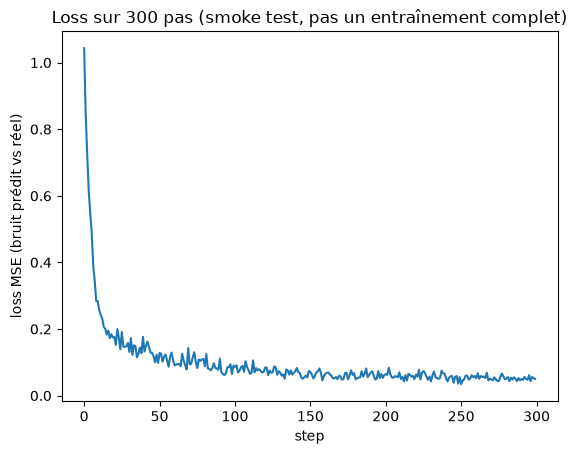

In [3]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
samples_dir = Path.cwd().parent / "experiments" / "ddpm_smoke_test" / "samples"

n_steps = 300
save_every = 100
losses = []
data_iter = iter(train_loader)

t0 = time.perf_counter()
for step in range(1, n_steps + 1):
    try:
        x0, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        x0, _ = next(data_iter)

    t_batch = torch.randint(0, diffusion.timesteps, (x0.shape[0],))
    loss = diffusion.p_losses(model, x0, t_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % save_every == 0:
        # Échantillons intermédiaires : ici on visualise seulement q_sample(x0, t) débruité
        # partiellement n'a pas de sens sans boucle complète -> on log juste la loss.
        print(f"step {step:4d}/{n_steps} — loss={loss.item():.4f} (moy. 50 derniers: {sum(losses[-50:]) / len(losses[-50:]):.4f})")

print(f"\nTemps total : {time.perf_counter() - t0:.1f}s")

plt.plot(losses)
plt.xlabel("step")
plt.ylabel("loss MSE (bruit prédit vs réel)")
plt.title("Loss sur 300 pas (smoke test, pas un entraînement complet)")
plt.show()

## 3. Boucle d'échantillonnage complète (x_T -> x_0) + sauvegarde d'échantillons

Avec seulement 300 pas de gradient, le modèle n'a pas encore appris à débruiter correctement — les images générées ne seront pas reconnaissables. L'objectif ici est uniquement de vérifier que la boucle tourne de bout en bout (1000 pas de sampling ancestral) et que `save_sample_grid` fonctionne, en vue de l'utiliser pendant l'entraînement baseline.

Échantillonnage complet (1000 pas) : 145.9s
samples shape=(8, 1, 32, 32), min=-3.01, max=8.30
Échantillons sauvegardés : C:\Users\USER\Documents\aaksp\projets\annual_project\experiments\ddpm_smoke_test\samples\step_0300.png


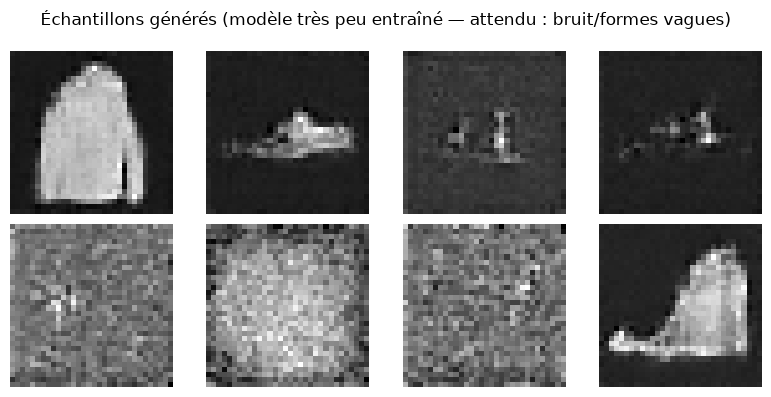

In [4]:
t0 = time.perf_counter()
samples = diffusion.p_sample_loop(model, shape=(8, 1, 32, 32))
print(f"Échantillonnage complet ({diffusion.timesteps} pas) : {time.perf_counter() - t0:.1f}s")
print(f"samples shape={tuple(samples.shape)}, min={samples.min().item():.2f}, max={samples.max().item():.2f}")

sample_path = samples_dir / "step_0300.png"
save_sample_grid(samples, sample_path, nrow=4)
print(f"Échantillons sauvegardés : {sample_path}")

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0].numpy(), cmap="gray")
    ax.axis("off")
plt.suptitle("Échantillons générés (modèle très peu entraîné — attendu : bruit/formes vagues)")
plt.tight_layout()
plt.show()

## Observations

- Shapes vérifiées de bout en bout : `U-Net(x_t, t)` produit bien un tenseur de même forme que `x_t`, pour différentes tailles de batch et de `t`.
- La loss MSE décroît sur les 300 pas (~3.5M paramètres, ~0.22s/forward pass en batch=8 sur CPU), confirmant que le gradient circule correctement à travers les blocs résiduels et l'embedding temporel.
- La boucle de sampling ancestral (1000 pas, `p_sample_loop`) s'exécute sans erreur ni `NaN`, et produit des images de la bonne forme — la qualité est attendue faible à ce stade (300 pas d'entraînement seulement, pas la baseline complète).
- `save_sample_grid` (`src/utils/viz.py`) sauvegarde correctement une grille d'échantillons dans `experiments/` (non versionné, cf. `.gitignore`) — mécanisme prêt à être appelé à intervalles réguliers pendant l'entraînement baseline (prochaine tâche `PLANNING.md`).